# Acte 1 — Le monde

## Objectif de ce notebook

Construire l'environnement dans lequel le world model va apprendre.

On va :
1. Créer une grille 10×10 avec ses règles de transition
2. Générer un dataset de transitions `(image_t, action_t, image_t+1)`
3. Visualiser quelques exemples pour vérifier que tout est cohérent

## Ce qu'on ne fait pas ici

On n'entraîne rien. On ne prédit rien. On construit uniquement le monde
et on collecte des observations — exactement comme dans le papier LeWM,
qui part de trajectoires brutes sans aucune supervision.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 1. L'environnement — GridWorld

Le monde est une grille 10×10. Les bords sont des murs fixes.
À l'intérieur, trois objets mobiles : l'agent, la boîte, la cible.

L'état du monde à chaque instant est représenté par une image 10×10
où chaque pixel encode la présence d'un objet :

- 0.0 → case vide (blanc)
- 0.3 → mur (gris foncé)
- 0.5 → agent (gris)
- 0.8 → boîte (rouge)
- 1.0 → cible (vert)

La classe `GridWorld` gère :
- l'initialisation du monde
- le rendu en image
- les règles de transition (déplacement, poussée, collision)

**Note sur l'initialisation** : la boîte est toujours placée dans
l'intérieur profond de la grille (loin des murs) pour garantir
la diversité du dataset — une boîte collée dès le départ au mur
ne pourrait plus jamais bouger.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from environment import GridWorld

## 2. Utilitaires de visualisation

`grid_to_rgb` est la fonction centrale de rendu : elle convertit
une grille 10×10 en image RGB. Toutes les autres fonctions
de visualisation l'appellent — si on veut changer une couleur,
on le fait ici, une seule fois.

In [3]:
def grid_to_rgb(grid):
    """
    Convertit une grille 10×10 (valeurs flottantes) en image RGB (numpy array).
    Centralise le mapping valeur → couleur pour toutes les visualisations.
    """
    rgb = np.zeros((grid.shape[0], grid.shape[1], 3), dtype=np.float64)
    rgb[grid == GridWorld.EMPTY]           = [1.0, 1.0, 1.0]
    rgb[grid == GridWorld.WALL]            = [0.3, 0.3, 0.3]
    rgb[grid == GridWorld.AGENT]           = [0.2, 0.4, 0.9]
    rgb[grid == GridWorld.BOX]             = [0.9, 0.2, 0.2]
    rgb[grid == GridWorld.TARGET]          = [0.2, 0.8, 0.2]
    rgb[grid == GridWorld.BOX_ON_TARGET]   = [0.9, 0.6, 0.0]
    rgb[grid == GridWorld.AGENT_ON_TARGET] = [0.4, 0.2, 0.9]
    rgb[grid == GridWorld.AGENT_ON_BOX]    = [0.9, 0.5, 0.0]
    return rgb

def show_grid_color(grid, title=""):
    """
    Affiche une grille 10×10 en couleurs lisibles avec légende.
    
    Chaque valeur de pixel est mappée à une couleur RGB :
    - blanc  : case vide
    - gris   : mur
    - bleu   : agent
    - rouge  : boîte
    - vert   : cible
    - orange : boîte sur cible (objectif atteint)
    - violet : agent sur cible
    """
    rgb = grid_to_rgb(grid)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")

    legend = [
        patches.Patch(color=[0.3, 0.3, 0.3], label="mur"),
        patches.Patch(color=[0.2, 0.4, 0.9], label="agent"),
        patches.Patch(color=[0.9, 0.2, 0.2], label="boîte"),
        patches.Patch(color=[0.2, 0.8, 0.2], label="cible"),
        patches.Patch(color=[0.9, 0.6, 0.0], label="boîte sur cible"),
        patches.Patch(color=[0.4, 0.2, 0.9], label="agent sur cible"),
    ]
    ax.legend(handles=legend, loc="upper right",
              bbox_to_anchor=(1.6, 1), fontsize=8)

    plt.tight_layout()
    plt.show()

## 3. Vérification des règles de transition

On teste les 3 cas :
- déplacement libre
- poussée de la boîte
- collision (mur ou blocage)

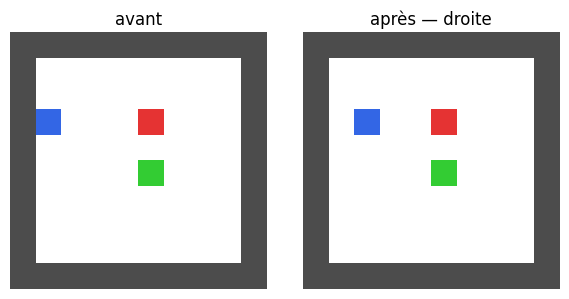

In [4]:
def show_transition(env, action, action_name):
    """Affiche avant / après une action."""
    before = env.render().copy()
    after  = env.step(action)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, grid, title in zip(axes, [before, after], ["avant", f"après — {action_name}"]):
        rgb = grid_to_rgb(grid)
        
        ax.imshow(rgb)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Test déplacement libre — on place l'agent loin de la boîte
env = GridWorld()
env.agent  = (3, 1)  # agent à gauche
env.box    = (3, 5)  # boîte à droite
env.target = (5, 5)  # cible en bas à droite
show_transition(env, 3, "droite")  # action 3 = droite

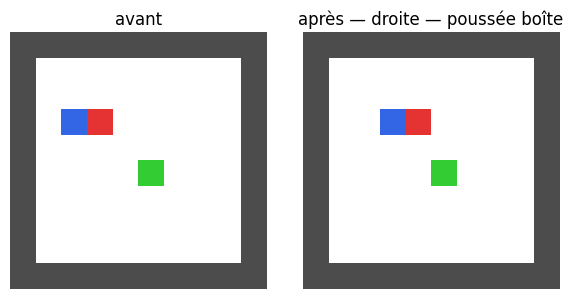

In [5]:
# Test poussée — l'agent est juste à gauche de la boîte
env = GridWorld()
env.agent  = (3, 2)  # agent
env.box    = (3, 3)  # boîte juste à droite de l'agent
env.target = (5, 5)  # cible ailleurs
show_transition(env, 3, "droite — poussée boîte")

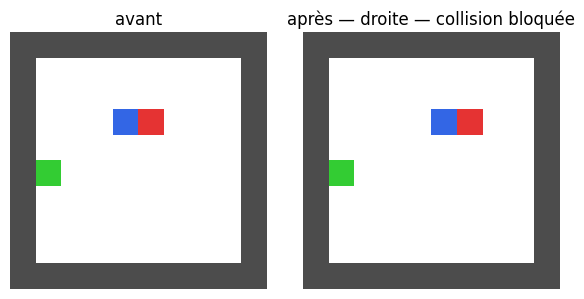

In [6]:
# Test collision — la boîte est collée au mur, impossible de la pousser
env = GridWorld()
env.agent  = (3, 4)  # agent
env.box    = (3, 5)  # boîte collée au mur droit
env.target = (5, 1)  # cible ailleurs
show_transition(env, 3, "droite — collision bloquée")

## 4. Génération du dataset

On génère un dataset de transitions `(image_t, action_t, image_t+1)`.

### V2 — Politique semi-dirigée

Dans la V1, l'agent agissait aléatoirement. Le problème : le modèle
apprenait la dynamique locale mais pas les positions absolues —
l'agent se baladait sans but, la boîte bougeait rarement.

Dans la V2, on utilise une politique semi-dirigée :
- avec probabilité `p_directed` : l'agent se dirige vers la boîte
- avec probabilité `1 - p_directed` : action aléatoire

Ça crée beaucoup plus d'interactions agent-boîte, ce qui force
le modèle à encoder les positions de façon plus précise.

On augmente aussi la longueur des épisodes (20 steps au lieu de 10)
pour capturer plus d'interactions par épisode.

Le dataset reste non supervisé : pas de récompense, pas de notion
de succès — uniquement de la dynamique enrichie.

In [7]:
def semi_directed_action(env, p_directed=0.7):
    """
    Politique semi-dirigée : avec probabilité p_directed,
    choisit l'action qui rapproche l'agent de la boîte.
    Sinon, action aléatoire.
    
    L'idée : créer plus d'interactions agent-boîte pour que
    le modèle apprenne à encoder les positions absolues.
    """
    if np.random.random() < p_directed:
        ar, ac = env.agent
        br, bc = env.box

        dr = br - ar  # différence de ligne
        dc = bc - ac  # différence de colonne

        # Choisir la direction dominante vers la boîte
        if abs(dr) >= abs(dc):
            return 1 if dr > 0 else 0  # bas ou haut
        else:
            return 3 if dc > 0 else 2  # droite ou gauche
    else:
        return np.random.randint(0, 4)  # action aléatoire


def generate_dataset(n_episodes=1000, episode_length=20, p_directed=0.7):
    """
    Génère un dataset de transitions (image_t, action_t, image_t+1).
    
    Utilise une politique semi-dirigée : l'agent se dirige vers
    la boîte avec probabilité p_directed, sinon agit aléatoirement.
    
    Paramètres :
        n_episodes     : nombre d'épisodes
        episode_length : nombre de pas par épisode
        p_directed     : probabilité d'action dirigée vers la boîte
    
    Retourne :
        observations : (N, 10, 10) float32
        actions      : (N,)        int64
        next_obs     : (N, 10, 10) float32
    """
    observations = []
    actions      = []
    next_obs     = []

    env = GridWorld()

    for episode in range(n_episodes):
        env.reset()

        for step in range(episode_length):
            obs_t  = env.render().copy()
            # Politique semi-dirigée au lieu d'aléatoire pur
            action = semi_directed_action(env, p_directed)
            obs_t1 = env.step(action).copy()

            observations.append(obs_t)
            actions.append(action)
            next_obs.append(obs_t1)

    return (
        np.array(observations, dtype=np.float32),
        np.array(actions,      dtype=np.int64),
        np.array(next_obs,     dtype=np.float32),
    )


# Génération — 1000 épisodes × 20 steps = 20 000 transitions
obs, acts, next_obs = generate_dataset(
    n_episodes=1000,
    episode_length=20,
    p_directed=0.7
)

print(f"Transitions générées : {len(obs)}")
print(f"Shape observations   : {obs.shape}")
print(f"Shape actions        : {acts.shape}")
print(f"Shape next_obs       : {next_obs.shape}")

Transitions générées : 20000
Shape observations   : (20000, 10, 10)
Shape actions        : (20000,)
Shape next_obs       : (20000, 10, 10)


## 5. Visualisation du dataset

On affiche quelques transitions pour vérifier que le dataset
est varié et cohérent : configurations initiales différentes,
actions différentes, résultats corrects.

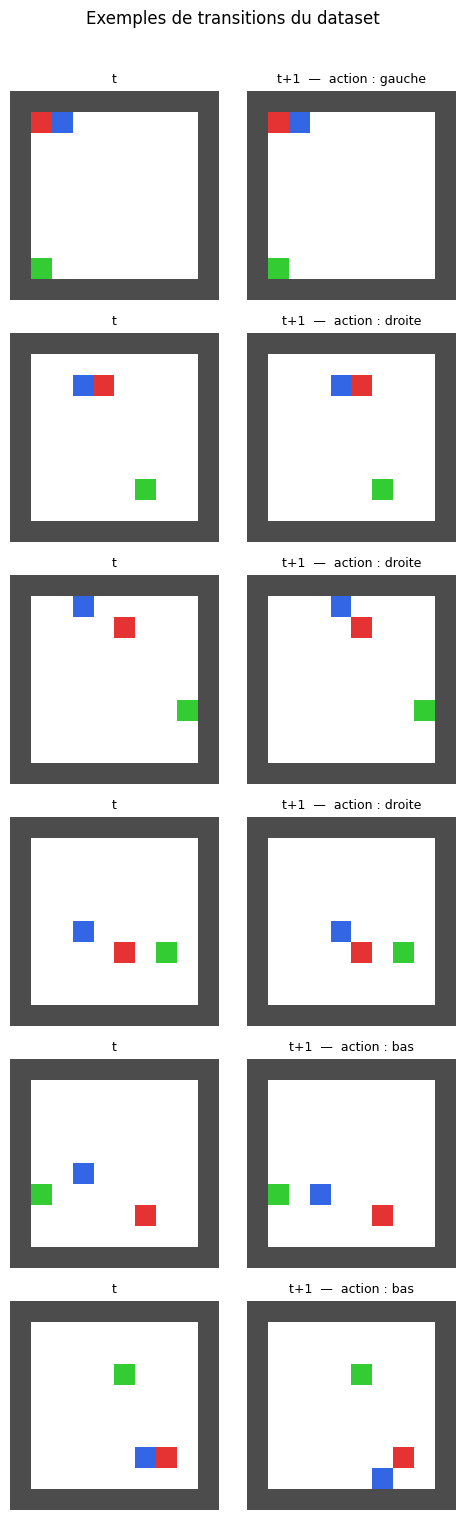

In [8]:
ACTION_NAMES = {0: "haut", 1: "bas", 2: "gauche", 3: "droite"}

def show_transitions(obs, acts, next_obs, n=6):
    """Affiche n transitions aléatoires du dataset."""
    indices = np.random.choice(len(obs), size=n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))

    for row, idx in enumerate(indices):
        for col, (grid, label) in enumerate([
            (obs[idx],      "t"),
            (next_obs[idx], f"t+1  —  action : {ACTION_NAMES[acts[idx]]}"),
        ]):
            rgb = grid_to_rgb(grid)
            axes[row, col].imshow(rgb)
            axes[row, col].set_title(label, fontsize=9)
            axes[row, col].axis("off")

    plt.suptitle("Exemples de transitions du dataset", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

show_transitions(obs, acts, next_obs, n=6)

## 6. Sauvegarde du dataset

In [9]:
np.save("../data/observations.npy", obs)
np.save("../data/actions.npy", acts)
np.save("../data/next_obs.npy", next_obs)

print("Dataset sauvegardé dans data/")
print(f"  observations.npy : {obs.shape}")
print(f"  actions.npy      : {acts.shape}")
print(f"  next_obs.npy     : {next_obs.shape}")

Dataset sauvegardé dans data/
  observations.npy : (20000, 10, 10)
  actions.npy      : (20000,)
  next_obs.npy     : (20000, 10, 10)


## Bonus — Jeu interactif

Pour explorer le monde manuellement avant d'entraîner le modèle.
Utilise les boutons ↑ ↓ ← → pour déplacer l'agent et pousser la boîte.
Le bouton Reset génère une nouvelle configuration aléatoire.

Note : les notebooks GitHub n'affichent pas les widgets interactifs.
Pour jouer, il faut exécuter le notebook localement.

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def play():
    env = GridWorld()
    out = widgets.Output()

    def render_current():
        with out:
            clear_output(wait=True)
            grid = env.render()
            rgb = grid_to_rgb(grid)
            fig, ax = plt.subplots(figsize=(3, 3))
            ax.imshow(rgb)
            ax.set_title("← ↑ → ↓ pour jouer")
            ax.axis("off")
            plt.tight_layout()
            plt.show()

    btn_haut    = widgets.Button(description="↑")
    btn_bas     = widgets.Button(description="↓")
    btn_gauche  = widgets.Button(description="←")
    btn_droite  = widgets.Button(description="→")
    btn_reset   = widgets.Button(description="Reset", button_style="warning")

    def on_action(action):
        env.step(action)
        render_current()

    btn_haut.on_click(lambda _: on_action(0))
    btn_bas.on_click(lambda _: on_action(1))
    btn_gauche.on_click(lambda _: on_action(2))
    btn_droite.on_click(lambda _: on_action(3))
    btn_reset.on_click(lambda _: (env.reset(), render_current()))

    controls = widgets.VBox([
        widgets.HBox([btn_haut]),
        widgets.HBox([btn_gauche, btn_bas, btn_droite]),
        btn_reset,
    ])

    display(widgets.HBox([controls, out]))
    render_current()

play()